In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.1/949.1 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [3]:
import os
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
import numpy as np
from sklearn.metrics import precision_recall_curve
import random
import matplotlib.image as mpimg
from PIL import Image, UnidentifiedImageError



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


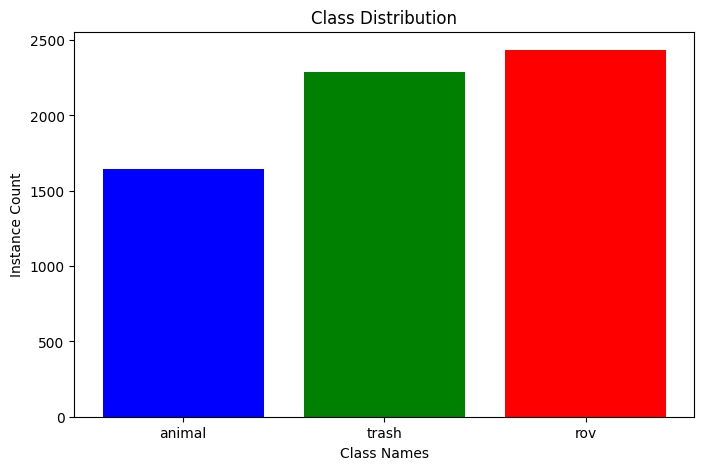

In [4]:
import yaml
import os
import cv2
import numpy as np
import json
import matplotlib.pyplot as plt
from collections import Counter

# Load YAML file
yaml_path = "/content/drive/MyDrive/C_V9/data.yaml"
with open(yaml_path, 'r') as file:
    data = yaml.safe_load(file)

train_images_path = data['train']
train_labels_path = train_images_path.replace("images", "labels")  # Assuming labels are in a parallel folder

# 1. Class Distribution Visualization
class_counts = Counter()
for label_file in os.listdir(train_labels_path):
    with open(os.path.join(train_labels_path, label_file), "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

class_names = data['names']
class_counts_named = {class_names[k]: v for k, v in class_counts.items()}

plt.figure(figsize=(8,5))
plt.bar(class_counts_named.keys(), class_counts_named.values(), color=['blue', 'green', 'red', 'purple'])
plt.xlabel("Class Names")
plt.ylabel("Instance Count")
plt.title("Class Distribution")
plt.show()


Sample image sizes: [[640 640]
 [640 640]
 [640 640]
 [640 640]
 [640 640]]


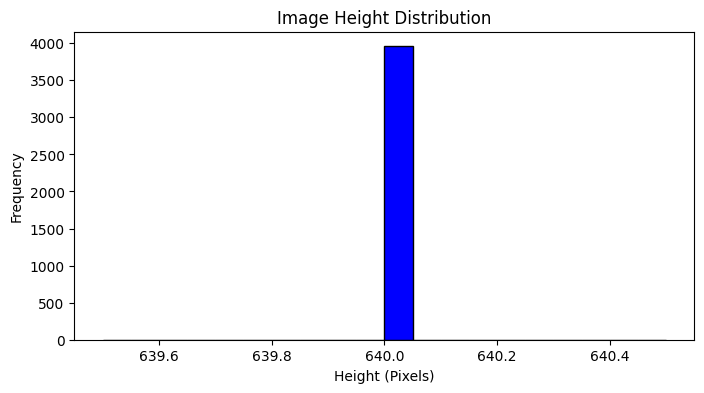

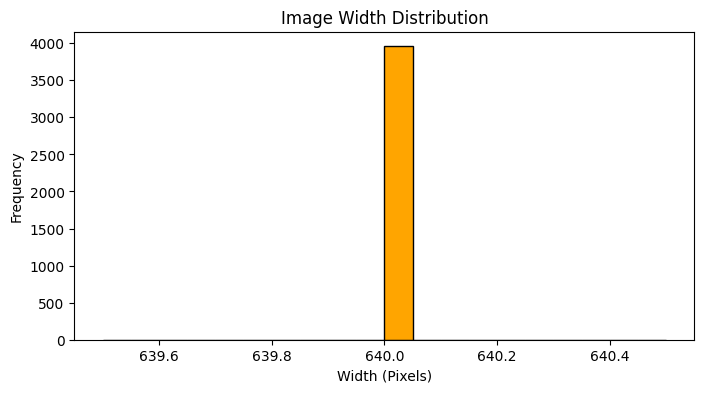

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_sizes = []

# Load images and get dimensions
for img_name in os.listdir(train_images_path):
    img_path = os.path.join(train_images_path, img_name)
    img = cv2.imread(img_path)

    if img is not None:
        height, width = img.shape[:2]
        image_sizes.append((height, width))

# Convert to NumPy array
if image_sizes:
    image_sizes = np.array(image_sizes)

    # Debugging: Print sample sizes
    print("Sample image sizes:", image_sizes[:5])

    # Plot Height Distribution
    plt.figure(figsize=(8, 4))
    plt.hist(image_sizes[:, 0], bins=20, color='blue', edgecolor='black')
    plt.xlabel("Height (Pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Height Distribution")
    plt.show()

    # Plot Width Distribution
    plt.figure(figsize=(8, 4))
    plt.hist(image_sizes[:, 1], bins=20, color='orange', edgecolor='black')
    plt.xlabel("Width (Pixels)")
    plt.ylabel("Frequency")
    plt.title("Image Width Distribution")
    plt.show()

else:
    print("No images found or read correctly.")


In [6]:
from ultralytics import YOLO

model = YOLO("yolov9m.pt")  # Choose 'n', 's', 'm', 'l'

results = model.train(
    data="/content/drive/MyDrive/C_V9/data.yaml",
    epochs=100,
    batch=32,
    imgsz=640,
    optimizer="AdamW",
    lr0=0.01,
    lrf=0.2,
    weight_decay=0.0005,
    momentum=0.937,
    cos_lr=True,
    warmup_epochs=3,
    augment=True,
    device="cuda",
    patience=10,
    verbose=True,
    project="/content/drive/MyDrive/runs_C3_m_0.01",  # Specify the project directory
    name="yolov9m"
)


100%|██████████| 39.1M/39.1M [00:00<00:00, 45.6MB/s]


Ultralytics 8.3.90 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=yolov9m.pt, data=/content/drive/MyDrive/C_V9/data.yaml, epochs=100, time=None, patience=10, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=/content/drive/MyDrive/runs_C3_m_0.01, name=yolov9m, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=True, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, sav

100%|██████████| 755k/755k [00:00<00:00, 131MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1    171648  ultralytics.nn.modules.block.RepNCSPELAN4    [64, 128, 128, 64, 1]         
  3                  -1  1    276960  ultralytics.nn.modules.block.AConv           [128, 240]                    
  4                  -1  1    629520  ultralytics.nn.modules.block.RepNCSPELAN4    [240, 240, 240, 120, 1]       
  5                  -1  1    778320  ultralytics.nn.modules.block.AConv           [240, 360]                    
  6                  -1  1   1414080  ultralytics.nn.modules.block.RepNCSPELAN4    [360, 360, 360, 180, 1]       
  7                  -1  1   1556160  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 270MB/s]


...

    100/100      17.6G     0.6821     0.5211      1.052         34        640: 100%|██████████| 124/124 [00:39<00:00,  3.17it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:06<00:00,  2.88it/s]

                   all       1133       1819      0.895       0.83      0.904      0.702



100 epochs completed in 1.315 hours.
Optimizer stripped from /content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/last.pt, 40.8MB
Optimizer stripped from /content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt, 40.8MB

Validating /content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt...
Ultralytics 8.3.90 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLOv9m summary (fused): 151 layers, 20,015,161 parameters, 0 gradients, 76.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:11<00:00,  1.62it/s]


                   all       1133       1819      0.888      0.843       0.91      0.711
                animal        287        458      0.861      0.743      0.835      0.556
                   rov        555        711      0.897      0.883      0.945      0.827
                 trash        585        650      0.908      0.902       0.95      0.749
Speed: 0.1ms preprocess, 5.4ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/drive/MyDrive/runs_C3_m_0.01/yolov9m


In [7]:
import yaml

def get_class_info(filepath):
    try:
        with open(filepath, "r") as file:
            data = yaml.safe_load(file)
            if data and "names" in data and isinstance(data["names"], list):
                class_info = []
                for i, name in enumerate(data["names"]):  # Use enumerate to get index (ID)
                    class_info.append({"name": name, "id": i})
                return class_info
            else:
                return None
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except yaml.YAMLError as e:
        print(f"Error: YAML parsing error: {e}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        return None

filepath = "/content/drive/MyDrive/C_V9/data.yaml"
class_data = get_class_info(filepath)

if class_data:
    for item in class_data:
        print(f"Class: {item['name']}, ID: {item['id']}")
else:
    print("No class information found or error occurred.")

Class: animal, ID: 0
Class: rov, ID: 1
Class: trash, ID: 2


In [8]:
# Save the trained model
model.save("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m.pt")

In [9]:
model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m.pt")

In [10]:
import os
import random
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the test directory
test_dir = "/content/drive/MyDrive/C_V9/test/images"

# Get a list of all images in the test directory
test_images = [os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Select 10 random images
random_images = random.sample(test_images, min(10, len(test_images)))

# Define the save directory
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict"  # Or any other path you prefer
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Process the selected images
for img_path in random_images:
    results = trained_model.predict(source=img_path, save=False, conf=0.25)  # Don't save directly with predict

    for i, result in enumerate(results): #enumerate to have an index for filename
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        save_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg") #Or whatever format you want

        annotated_image = result.plot()
        import cv2
        cv2.imwrite(save_path, annotated_image)

        print(f"Image: {img_path}, Class: {result.boxes.cls}, Confidence: {result.boxes.conf}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000314_frame0000026_jpg.rf.d79d32310a6b1e72835576da52a205f2.jpg: 640x640 1 trash, 16.3ms
Speed: 2.2ms preprocess, 16.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000314_frame0000026_jpg.rf.d79d32310a6b1e72835576da52a205f2.jpg, Class: tensor([2.], device='cuda:0'), Confidence: tensor([0.9079], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000285_frame0000129_jpg.rf.66d1ab569b4b2c612afd4de5341383e7.jpg: 640x640 1 rov, 16.6ms
Speed: 2.1ms preprocess, 16.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000285_frame0000129_jpg.rf.66d1ab569b4b2c612afd4de5341383e7.jpg, Class: tensor([1.], device='cuda:0'), Confidence: tensor([0.9360], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000054_frame0000001_jpg.rf.026c4bb5b79b447e413806676ee1db12.jpg: 

In [11]:
import os
import random
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the test directory
test_dir = "/content/drive/MyDrive/C_V9/test/images"

# Get a list of all images in the test directory
test_images = [os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Select 10 random images
random_images = random.sample(test_images, min(10, len(test_images)))

# Define the save directory
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict1"  # Or any other path you prefer
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Process the selected images
for img_path in random_images:
    results = trained_model.predict(source=img_path, save=False, conf=0.25)  # Don't save directly with predict

    for i, result in enumerate(results): #enumerate to have an index for filename
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        save_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg") #Or whatever format you want

        annotated_image = result.plot()
        import cv2
        cv2.imwrite(save_path, annotated_image)

        print(f"Image: {img_path}, Class: {result.boxes.cls}, Confidence: {result.boxes.conf}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000155_frame0000026_jpg.rf.b84984132125d19f61bb16316cbee1f7.jpg: 640x640 1 rov, 17.4ms
Speed: 1.9ms preprocess, 17.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000155_frame0000026_jpg.rf.b84984132125d19f61bb16316cbee1f7.jpg, Class: tensor([1.], device='cuda:0'), Confidence: tensor([0.9453], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000552_frame0000106_jpg.rf.9d2093e5dfcd98cf3d5588c6bce56382.jpg: 640x640 1 animal, 1 trash, 16.5ms
Speed: 1.9ms preprocess, 16.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000552_frame0000106_jpg.rf.9d2093e5dfcd98cf3d5588c6bce56382.jpg, Class: tensor([2., 0.], device='cuda:0'), Confidence: tensor([0.8212, 0.2735], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000123_frame0000016_jpg.rf.c7cc14e7d247e107

In [12]:
import os
import random
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the test directory
test_dir = "/content/drive/MyDrive/C_V9/test/images"

# Get a list of all images in the test directory
test_images = [os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Select 10 random images
random_images = random.sample(test_images, min(10, len(test_images)))

# Define the save directory
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict2"  # Or any other path you prefer
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Process the selected images
for img_path in random_images:
    results = trained_model.predict(source=img_path, save=False, conf=0.25)  # Don't save directly with predict

    for i, result in enumerate(results): #enumerate to have an index for filename
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        save_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg") #Or whatever format you want

        annotated_image = result.plot()
        import cv2
        cv2.imwrite(save_path, annotated_image)

        print(f"Image: {img_path}, Class: {result.boxes.cls}, Confidence: {result.boxes.conf}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000106_frame0000001_jpg.rf.a100691edffcfc18f86f866224cead41.jpg: 640x640 4 animals, 15.7ms
Speed: 1.9ms preprocess, 15.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000106_frame0000001_jpg.rf.a100691edffcfc18f86f866224cead41.jpg, Class: tensor([0., 0., 0., 0.], device='cuda:0'), Confidence: tensor([0.7701, 0.6613, 0.6429, 0.2717], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000075_frame0000001_jpg.rf.f1026c32b8bd772b516b460751d129c7.jpg: 640x640 2 rovs, 16.1ms
Speed: 1.9ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000075_frame0000001_jpg.rf.f1026c32b8bd772b516b460751d129c7.jpg, Class: tensor([1., 1.], device='cuda:0'), Confidence: tensor([0.9086, 0.7749], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000165_frame00

In [13]:
import os
import random
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the test directory
test_dir = "/content/drive/MyDrive/C_V9/test/images"

# Get a list of all images in the test directory
test_images = [os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Select 10 random images
random_images = random.sample(test_images, min(10, len(test_images)))

# Define the save directory
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict3"  # Or any other path you prefer
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Process the selected images
for img_path in random_images:
    results = trained_model.predict(source=img_path, save=False, conf=0.25)  # Don't save directly with predict

    for i, result in enumerate(results): #enumerate to have an index for filename
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        save_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg") #Or whatever format you want

        annotated_image = result.plot()
        import cv2
        cv2.imwrite(save_path, annotated_image)

        print(f"Image: {img_path}, Class: {result.boxes.cls}, Confidence: {result.boxes.conf}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000303_frame0000003_jpg.rf.317602333de1b5f6eb34f2369d281fa6.jpg: 640x640 (no detections), 17.1ms
Speed: 1.9ms preprocess, 17.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000303_frame0000003_jpg.rf.317602333de1b5f6eb34f2369d281fa6.jpg, Class: tensor([], device='cuda:0'), Confidence: tensor([], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000437_frame0000036_jpg.rf.4d713a45ac4733f9ce464940be9ad588.jpg: 640x640 1 animal, 15.7ms
Speed: 1.9ms preprocess, 15.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000437_frame0000036_jpg.rf.4d713a45ac4733f9ce464940be9ad588.jpg, Class: tensor([0.], device='cuda:0'), Confidence: tensor([0.9330], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000171_frame0000006_jpg.rf.be26c2b7b1c6b9c50e4ec22740b41e1c.jp

In [14]:
import os
import random
from ultralytics import YOLO

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the test directory
test_dir = "/content/drive/MyDrive/C_V9/test/images"

# Get a list of all images in the test directory
test_images = [os.path.join(test_dir, img) for img in os.listdir(test_dir) if img.endswith(('.png', '.jpg', '.jpeg'))]

# Select 10 random images
random_images = random.sample(test_images, min(10, len(test_images)))

# Define the save directory
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict4"  # Or any other path you prefer
os.makedirs(save_dir, exist_ok=True)  # Create the directory if it doesn't exist

# Process the selected images
for img_path in random_images:
    results = trained_model.predict(source=img_path, save=False, conf=0.25)  # Don't save directly with predict

    for i, result in enumerate(results): #enumerate to have an index for filename
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        save_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg") #Or whatever format you want

        annotated_image = result.plot()
        import cv2
        cv2.imwrite(save_path, annotated_image)

        print(f"Image: {img_path}, Class: {result.boxes.cls}, Confidence: {result.boxes.conf}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000132_frame0000104_jpg.rf.92e1a96cb07947dc1ea7e6a1c1bd0723.jpg: 640x640 2 animals, 16.1ms
Speed: 2.0ms preprocess, 16.1ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000132_frame0000104_jpg.rf.92e1a96cb07947dc1ea7e6a1c1bd0723.jpg, Class: tensor([0., 0.], device='cuda:0'), Confidence: tensor([0.7462, 0.4081], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000160_frame0000017_jpg.rf.88345c6e21905092c626ab9e774f789a.jpg: 640x640 1 animal, 2 rovs, 16.2ms
Speed: 1.9ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000160_frame0000017_jpg.rf.88345c6e21905092c626ab9e774f789a.jpg, Class: tensor([0., 1., 1.], device='cuda:0'), Confidence: tensor([0.7564, 0.6177, 0.4415], device='cuda:0')

image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000105_frame0000

In [15]:
import os
from ultralytics import YOLO
import cv2

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the path to the specific image
image_path = "/content/drive/MyDrive/C_V9/test/images/vid_000434_frame0000021_jpg.rf.3d67289386c659e2620602397b9060b7.jpg"

# Define the directory to save the results
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict5"  # Create this directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()

try:
    results = trained_model.predict(source=image_path, save=False, conf=0.25)  # save=False

    for i, result in enumerate(results):  # Iterate through results (even if it's one image)
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        save_image_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg")  # Save image path
        save_results_path = os.path.join(save_dir, f"{base_name}_results_{i}.txt") #Save results path

        annotated_image = result.plot()
        cv2.imwrite(save_image_path, annotated_image)  # Save the annotated image

        print(f"Image: {image_path}")
        boxes = result.boxes

        with open(save_results_path, "w") as f: #Open a file to write the results
            if boxes:
                for box in boxes:
                    xyxy = box.xyxy[0].tolist()
                    xywh = box.xywh[0].tolist()
                    cls = int(box.cls[0])
                    conf = float(box.conf[0])
                    print(f" - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
                    f.write(f"{cls} {conf} {xyxy[0]} {xyxy[1]} {xyxy[2]} {xyxy[3]}\n") #Write the results to the file
            else:
                print(" No objects detected in this image.")
                f.write("No objects detected\n") #Write no objects detected to the file
        print(f"Results saved to {save_results_path}")

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000434_frame0000021_jpg.rf.3d67289386c659e2620602397b9060b7.jpg: 640x640 3 animals, 15.6ms
Speed: 1.9ms preprocess, 15.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000434_frame0000021_jpg.rf.3d67289386c659e2620602397b9060b7.jpg
 - Box (xyxy): [159.95684814453125, 275.1794738769531, 389.4703369140625, 369.6284484863281], Box (xywh): [274.7135925292969, 322.4039611816406, 229.51348876953125, 94.448974609375], Class: 0, Confidence: 0.9114018082618713
 - Box (xyxy): [143.6519775390625, 372.2037048339844, 409.1416015625, 504.1281433105469], Box (xywh): [276.39678955078125, 438.1659240722656, 265.4896240234375, 131.9244384765625], Class: 0, Confidence: 0.901616096496582
 - Box (xyxy): [82.44607543945312, 144.8995361328125, 146.329833984375, 264.3326416015625], Box (xywh): [114.38795471191406, 204.6160888671875, 63.883758544921875, 119.43310546875], Class: 0, Confi

In [16]:
import os
from ultralytics import YOLO
import cv2

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the path to the specific image
image_path = "/content/drive/MyDrive/C_V9/test/images/vid_000444_frame0000108_jpg.rf.b3edd8abfd44341863aa9c53aa95e356.jpg"

# Define the directory to save the results
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict6"  # Create this directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()

try:
    results = trained_model.predict(source=image_path, save=False, conf=0.25)  # save=False

    for i, result in enumerate(results):  # Iterate through results (even if it's one image)
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        save_image_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg")  # Save image path
        save_results_path = os.path.join(save_dir, f"{base_name}_results_{i}.txt") #Save results path

        annotated_image = result.plot()
        cv2.imwrite(save_image_path, annotated_image)  # Save the annotated image

        print(f"Image: {image_path}")
        boxes = result.boxes

        with open(save_results_path, "w") as f: #Open a file to write the results
            if boxes:
                for box in boxes:
                    xyxy = box.xyxy[0].tolist()
                    xywh = box.xywh[0].tolist()
                    cls = int(box.cls[0])
                    conf = float(box.conf[0])
                    print(f" - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
                    f.write(f"{cls} {conf} {xyxy[0]} {xyxy[1]} {xyxy[2]} {xyxy[3]}\n") #Write the results to the file
            else:
                print(" No objects detected in this image.")
                f.write("No objects detected\n") #Write no objects detected to the file
        print(f"Results saved to {save_results_path}")

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000444_frame0000108_jpg.rf.b3edd8abfd44341863aa9c53aa95e356.jpg: 640x640 3 animals, 15.8ms
Speed: 2.0ms preprocess, 15.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000444_frame0000108_jpg.rf.b3edd8abfd44341863aa9c53aa95e356.jpg
 - Box (xyxy): [89.65486907958984, 190.21713256835938, 207.94949340820312, 355.0288391113281], Box (xywh): [148.80218505859375, 272.62298583984375, 118.29462432861328, 164.81170654296875], Class: 0, Confidence: 0.9007549285888672
 - Box (xyxy): [336.3797912597656, 240.0247802734375, 451.6338806152344, 445.68817138671875], Box (xywh): [394.0068359375, 342.8564758300781, 115.25408935546875, 205.66339111328125], Class: 0, Confidence: 0.8810972571372986
 - Box (xyxy): [514.577880859375, 207.66934204101562, 635.866455078125, 331.9133605957031], Box (xywh): [575.22216796875, 269.7913513183594, 121.28857421875, 124.2440185546875], Class: 0, 

In [17]:
import os
from ultralytics import YOLO
import cv2

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the path to the specific image
image_path = "/content/drive/MyDrive/C_V9/test/images/vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261.jpg"

# Define the directory to save the results
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict7"  # Create this directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()

try:
    results = trained_model.predict(source=image_path, save=False, conf=0.25)  # save=False

    for i, result in enumerate(results):  # Iterate through results (even if it's one image)
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        save_image_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg")  # Save image path
        save_results_path = os.path.join(save_dir, f"{base_name}_results_{i}.txt") #Save results path

        annotated_image = result.plot()
        cv2.imwrite(save_image_path, annotated_image)  # Save the annotated image

        print(f"Image: {image_path}")
        boxes = result.boxes

        with open(save_results_path, "w") as f: #Open a file to write the results
            if boxes:
                for box in boxes:
                    xyxy = box.xyxy[0].tolist()
                    xywh = box.xywh[0].tolist()
                    cls = int(box.cls[0])
                    conf = float(box.conf[0])
                    print(f" - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
                    f.write(f"{cls} {conf} {xyxy[0]} {xyxy[1]} {xyxy[2]} {xyxy[3]}\n") #Write the results to the file
            else:
                print(" No objects detected in this image.")
                f.write("No objects detected\n") #Write no objects detected to the file
        print(f"Results saved to {save_results_path}")

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261.jpg: 640x640 1 animal, 1 trash, 19.4ms
Speed: 2.0ms preprocess, 19.4ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261.jpg
 - Box (xyxy): [114.47293090820312, 371.96942138671875, 172.1103515625, 430.55328369140625], Box (xywh): [143.29164123535156, 401.2613525390625, 57.637420654296875, 58.5838623046875], Class: 0, Confidence: 0.8221979141235352
 - Box (xyxy): [83.89352416992188, 428.50927734375, 128.5915069580078, 499.56005859375], Box (xywh): [106.24251556396484, 464.03466796875, 44.69798278808594, 71.05078125], Class: 2, Confidence: 0.8186386823654175
Results saved to /content/drive/MyDrive/runs_C3_m_0.01/predict7/vid_000532_frame0000160_jpg.rf.9ffce0025fcac8c4e5ff992233ae1261_results_0.txt


In [18]:
import os
from ultralytics import YOLO
import cv2

# Load the trained model
trained_model = YOLO("/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/weights/best.pt")

# Define the path to the specific image
image_path = "/content/drive/MyDrive/C_V9/test/images/vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484.jpg"

# Define the directory to save the results
save_dir = "/content/drive/MyDrive/runs_C3_m_0.01/predict8"  # Create this directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# Check if the image file exists
if not os.path.exists(image_path):
    print(f"Error: Image file not found at {image_path}")
    exit()

try:
    results = trained_model.predict(source=image_path, save=False, conf=0.25)  # save=False

    for i, result in enumerate(results):  # Iterate through results (even if it's one image)
        base_name = os.path.splitext(os.path.basename(image_path))[0]
        save_image_path = os.path.join(save_dir, f"{base_name}_pred_{i}.jpg")  # Save image path
        save_results_path = os.path.join(save_dir, f"{base_name}_results_{i}.txt") #Save results path

        annotated_image = result.plot()
        cv2.imwrite(save_image_path, annotated_image)  # Save the annotated image

        print(f"Image: {image_path}")
        boxes = result.boxes

        with open(save_results_path, "w") as f: #Open a file to write the results
            if boxes:
                for box in boxes:
                    xyxy = box.xyxy[0].tolist()
                    xywh = box.xywh[0].tolist()
                    cls = int(box.cls[0])
                    conf = float(box.conf[0])
                    print(f" - Box (xyxy): {xyxy}, Box (xywh): {xywh}, Class: {cls}, Confidence: {conf}")
                    f.write(f"{cls} {conf} {xyxy[0]} {xyxy[1]} {xyxy[2]} {xyxy[3]}\n") #Write the results to the file
            else:
                print(" No objects detected in this image.")
                f.write("No objects detected\n") #Write no objects detected to the file
        print(f"Results saved to {save_results_path}")

except Exception as e:
    print(f"An error occurred during prediction: {e}")


image 1/1 /content/drive/MyDrive/C_V9/test/images/vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484.jpg: 640x640 1 trash, 16.1ms
Speed: 1.9ms preprocess, 16.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Image: /content/drive/MyDrive/C_V9/test/images/vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484.jpg
 - Box (xyxy): [163.6103515625, 411.77667236328125, 316.5556945800781, 499.79083251953125], Box (xywh): [240.08302307128906, 455.78375244140625, 152.94534301757812, 88.01416015625], Class: 2, Confidence: 0.9165360331535339
Results saved to /content/drive/MyDrive/runs_C3_m_0.01/predict8/vid_000553_frame0000028_jpg.rf.f2200b6795689fc919d12fa961fae484_results_0.txt


In [19]:
import pandas as pd

# Load the results.csv file
file_path = "/content/drive/MyDrive/runs_C3_m_0.01/yolov9m/results.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure
df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,85.2431,1.82233,3.14823,1.90910,0.00102,0.18260,0.00069,0.00024,3.92591,inf,153.16200,0.070242,0.003306,0.003306
1,2,134.3740,1.83393,2.71713,1.92864,0.69662,0.01828,0.01217,0.00444,2.28948,26.09500,2.81910,0.040241,0.006638,0.006638
2,3,182.0690,1.68097,2.47537,1.79656,0.00962,0.09456,0.00418,0.00157,2.67512,50.25620,3.31950,0.010234,0.009965,0.009965
3,4,229.3470,1.61835,2.37013,1.73197,0.26842,0.32060,0.17127,0.07999,1.71607,8.09695,2.02517,0.009982,0.009982,0.009982
4,5,276.4710,1.56187,2.26213,1.68401,0.13523,0.17492,0.08969,0.04254,1.90982,4.82047,2.16783,0.009968,0.009968,0.009968


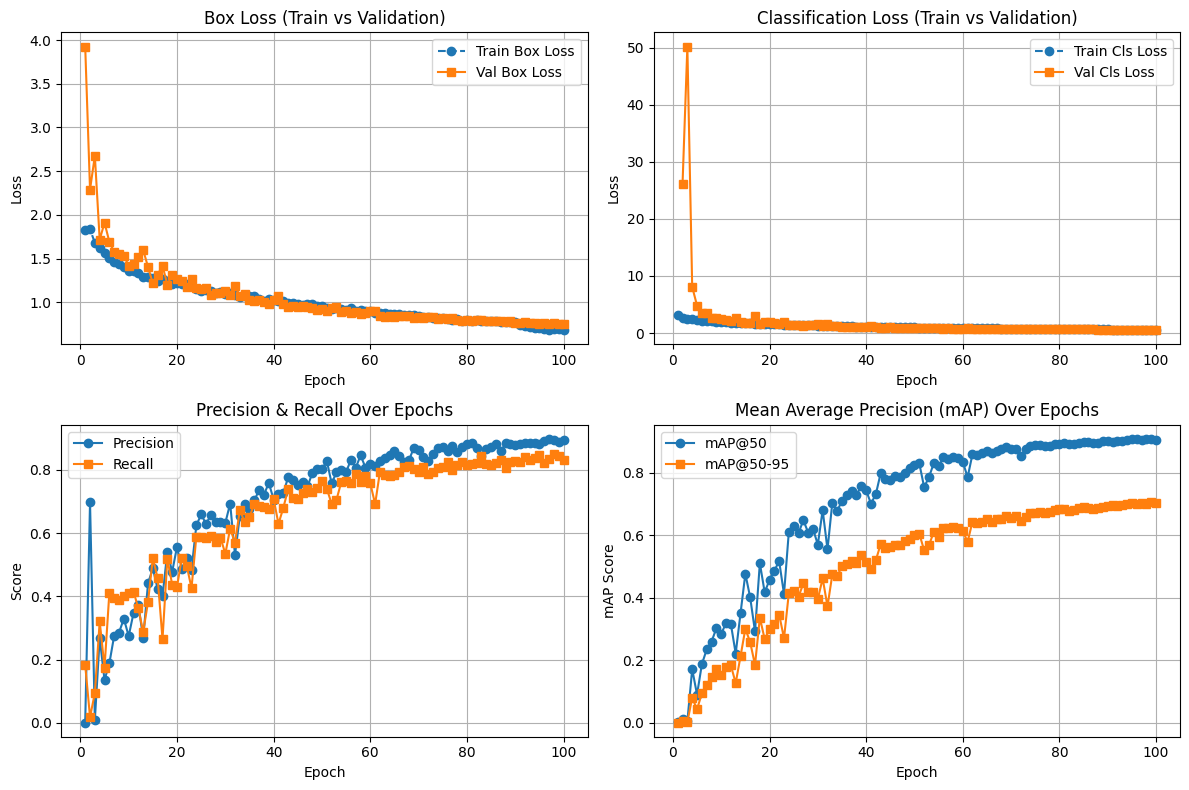

In [20]:
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(12, 8))

# Loss Curves (Training & Validation)
plt.subplot(2, 2, 1)
plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss", linestyle="--", marker="o")
plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Box Loss (Train vs Validation)")
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss", linestyle="--", marker="o")
plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Classification Loss (Train vs Validation)")
plt.legend()
plt.grid()

# Precision & Recall Over Epochs
plt.subplot(2, 2, 3)
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision", linestyle="-", marker="o")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision & Recall Over Epochs")
plt.legend()
plt.grid()

# mAP Scores Over Epochs
plt.subplot(2, 2, 4)
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@50", linestyle="-", marker="o")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@50-95", linestyle="-", marker="s")
plt.xlabel("Epoch")
plt.ylabel("mAP Score")
plt.title("Mean Average Precision (mAP) Over Epochs")
plt.legend()
plt.grid()

# Show all plots
plt.tight_layout()
plt.show()
